# Assignment 5: Reducing High-Dimensional Data with PCA

**Student Name:** Trace Thomason

**Date:** 2-27-26

---

## Assignment Overview

You've joined the data science team at FitTrack Analytics, a company that develops fall detection systems for elderly care facilities. Their wearable devices capture 561 sensor features from accelerometer and gyroscope readings. Your task: use Principal Component Analysis (PCA) to compress this high-dimensional data into something you can visualize, understand, and build reliable models from.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [13]:
# Load the Human Activity Recognition dataset
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# Remove non-feature columns (subject and Activity)
X_train = train_df.drop(["Activity", "subject"], axis=1)
y_train = train_df["Activity"]

X_test = test_df.drop(["Activity", "subject"], axis=1)
y_test = test_df["Activity"]

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Unique activities: {y_train.nunique()}")
print("="*80)



CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 561)
Test set shape: (2947, 561)
Number of features: 561
Unique activities: 6


---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

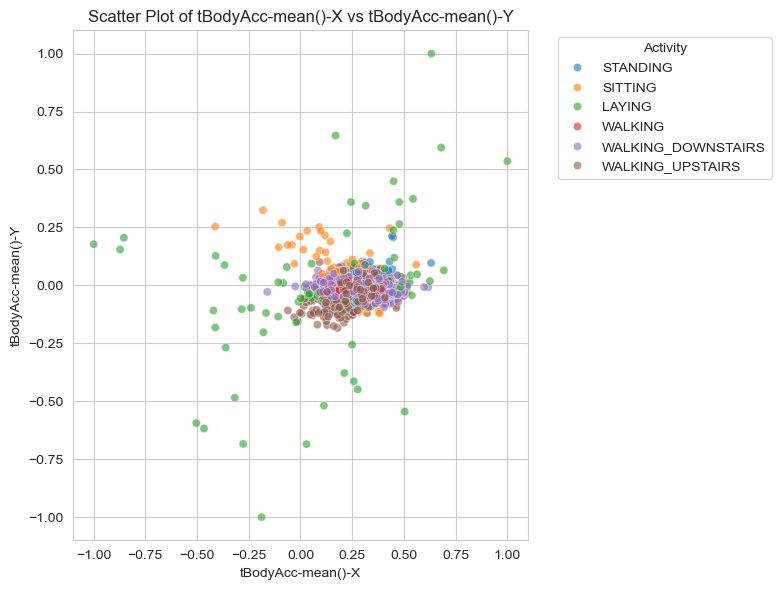

In [14]:
# Select any two features (first two columns)
feature_1 = X_train.columns[0]
feature_2 = X_train.columns[1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train[feature_1],
    y=X_train[feature_2],
    hue=y_train,
    palette="tab10",
    alpha=0.6
)

plt.title(f"Scatter Plot of {feature_1} vs {feature_2}")
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend(title="Activity", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()




### Check Feature Correlations

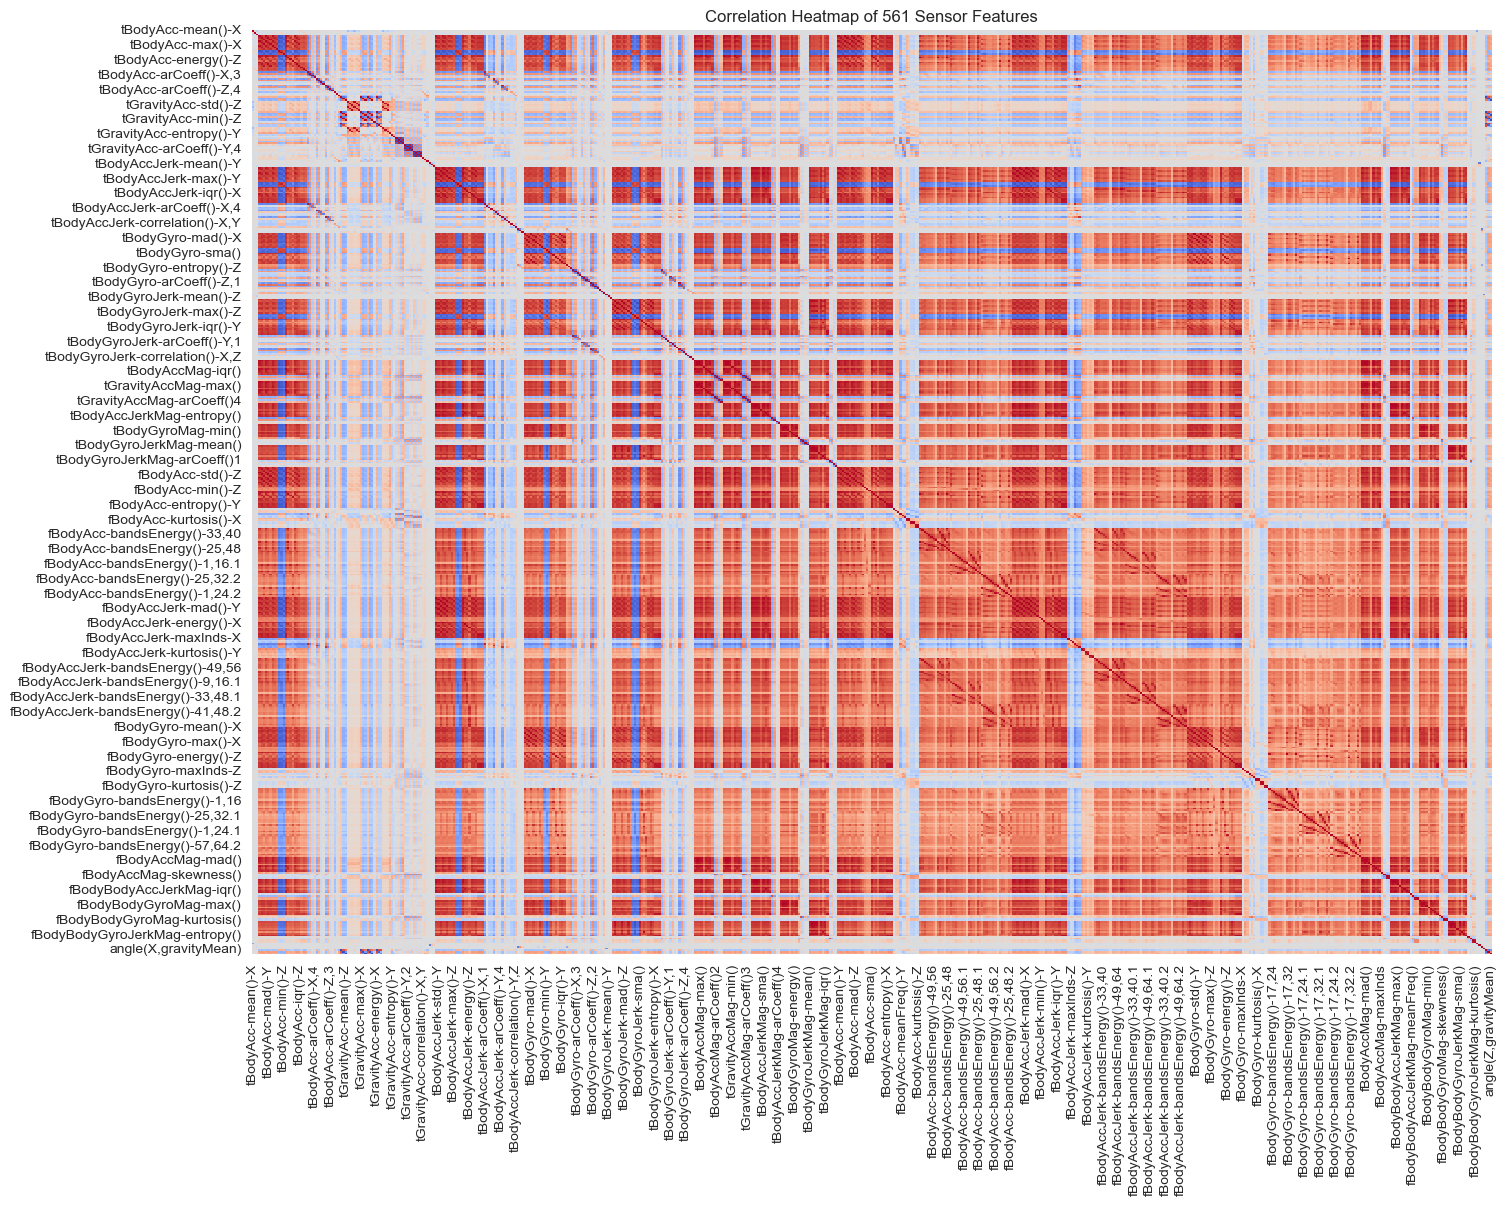

In [15]:
# Compute correlation matrix
corr_matrix = X_train.corr()

# Create a correlation heatmap of all 561 features
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, cbar=False)
plt.title("Correlation Heatmap of 561 Sensor Features")
plt.show()


### Train Baseline Model

In [16]:
start_time = time.time()

# Train RandomForestClassifier
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)

# Calculate baseline training time
baseline_time = time.time() - start_time

# Calculate accuracy on test set
y_pred = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 561
Accuracy: 0.9267
Training time: 28.98 seconds


### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?

Working with 561 sensor features made the data extremely difficult to interpret because meaningful patterns cannot be visualized beyond two or three dimensions. The scatter plot of two raw features showed significant overlap between activities, and the correlation heatmap was too dense to clearly identify specific relationships, although it suggested substantial redundancy among features. Additionally, the baseline model required considerable training time, highlighting how high dimensionality increases computational cost and model complexity.

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [17]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape}")
print("="*80)



CHECKPOINT: Features Standardized
Scaled training shape: (7352, 561)


### Apply PCA for 2 Components

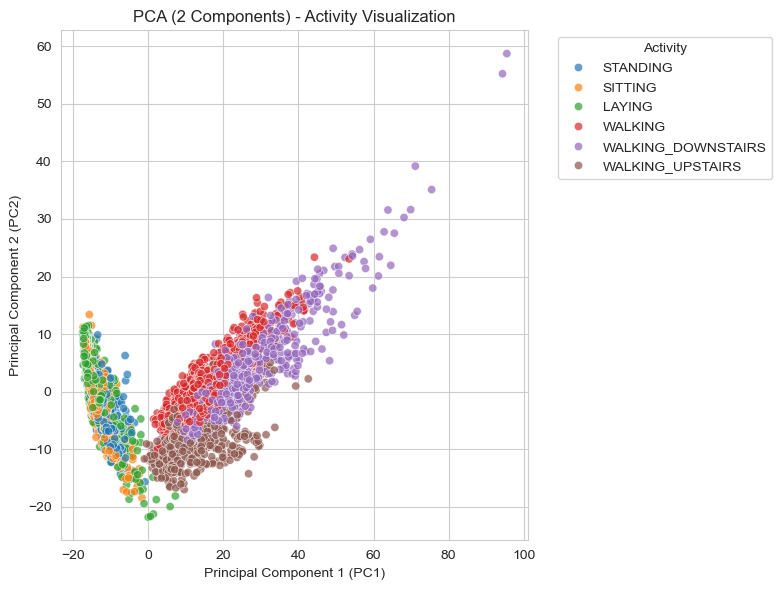

In [18]:
# Apply PCA with 2 components
pca_2d = PCA(n_components=2)

X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d = pca_2d.transform(X_test_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(X_train_pca_2d, columns=["PC1", "PC2"])
pca_df["Activity"] = y_train.values

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Activity",
    palette="tab10",
    alpha=0.7
)

plt.title("PCA (2 Components) - Activity Visualization")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Activity", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()



### Apply PCA for 3 Components

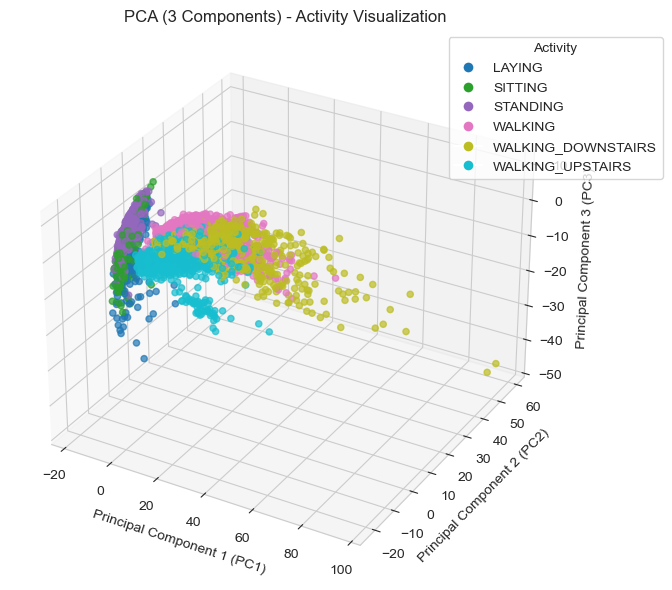

In [19]:
# Apply PCA with 3 components
pca_3d = PCA(n_components=3)

X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d = pca_3d.transform(X_test_scaled)

# Convert activity labels to numeric codes for coloring
activity_codes = y_train.astype("category").cat.codes

# Create 3D scatter plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca_3d[:, 0],
    X_train_pca_3d[:, 1],
    X_train_pca_3d[:, 2],
    c=activity_codes,
    cmap="tab10",
    alpha=0.7
)

ax.set_title("PCA (3 Components) - Activity Visualization")
ax.set_xlabel("Principal Component 1 (PC1)")
ax.set_ylabel("Principal Component 2 (PC2)")
ax.set_zlabel("Principal Component 3 (PC3)")

# Create legend manually
legend_labels = y_train.astype("category").cat.categories
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=scatter.cmap(scatter.norm(i)),
                      markersize=8) 
           for i in range(len(legend_labels))]

ax.legend(handles, legend_labels, title="Activity", bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()




### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?

After applying PCA, clear structure emerges in the data that was not visible in the original 561-dimensional space. In both the 2D and 3D visualizations, walking-related activities (walking, walking upstairs, and walking downstairs) cluster together along a similar trajectory, while stationary activities (sitting, standing, and lying) form a separate, tighter group. The 3D visualization provides even better separation between similar activities, showing that the principal components successfully capture the most important movement patterns in the dataset.

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

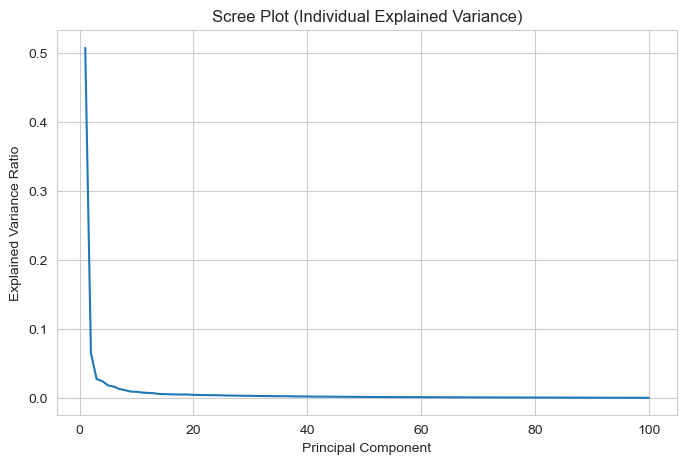

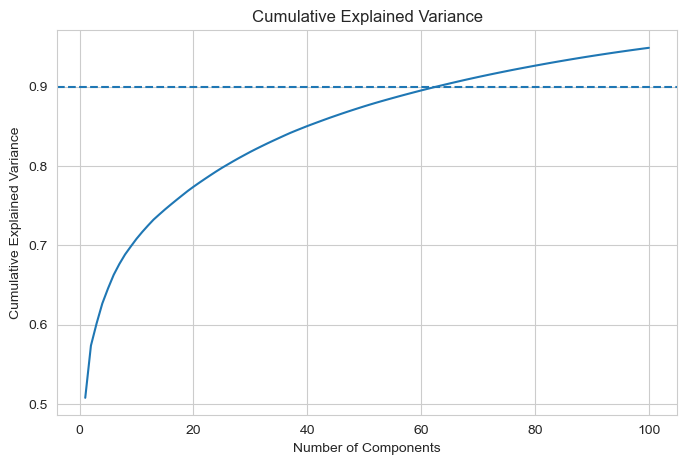

In [20]:
# Fit PCA with 100 components
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

# Get explained variance ratio
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance ratio (Scree Plot)
plt.figure(figsize=(8,5))
plt.plot(range(1, 101), explained_variance)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (Individual Explained Variance)")
plt.show()

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, 101), cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.axhline(y=0.90, linestyle='--')  # 90% reference line
plt.show()



### Analyze the Elbow

In [21]:
# Compute cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components needed for each threshold
components_75 = np.argmax(cumulative_variance >= 0.75) + 1
components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
print(f"Components for 75% variance: {components_75}")
print(f"Components for 80% variance: {components_80}")
print(f"Components for 90% variance: {components_90}")
print("="*80)


EXPLAINED VARIANCE ANALYSIS
Components for 75% variance: 16
Components for 80% variance: 26
Components for 90% variance: 63


### Select Optimal Components

In [23]:
# Set your chosen optimal number of components
optimal_components = components_80  

print(f"Chosen number of components: {optimal_components}")


Chosen number of components: 26


In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?

Based on the scree plot and cumulative variance curve, I selected 26 components as the optimal number because this is where the curve begins to flatten, indicating diminishing returns. These 26 components capture approximately 80% of the total variance in the dataset. The tradeoff is that while some information is lost compared to retaining 90% variance, the significant reduction from 561 to 26 features greatly improves computational efficiency and model simplicity while still preserving most meaningful patterns.

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [24]:
# Apply PCA with your optimal number of components
pca_optimal = PCA(n_components=optimal_components)

X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape}")
print("="*80)



CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 26)


### Train PCA Model

In [25]:
# To measure training time
start_time = time.time()

# Train RandomForestClassifier using PCA features
pca_model = RandomForestClassifier(n_estimators=100, random_state=42)
pca_model.fit(X_train_pca, y_train)

# Calculate accuracy on test set
y_pred_pca = pca_model.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

# Record training time
pca_time = time.time() - start_time

print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy:.4f}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 26
Accuracy: 0.8585
Training time: 7.49 seconds


### Create Comparison Table

In [26]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# Calculate speedup factor
speedup = baseline_time / pca_time

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x")
print("="*80)



MODEL COMPARISON
                  Model  Features  Accuracy  Training Time (s)
Baseline (All Features)       561  0.926705          28.980607
              PCA Model        26  0.858500           7.488215

Speedup factor: 3.87x


### Final Analysis

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- Did PCA improve or hurt accuracy? 
- How much faster was training? 
- When would you recommend using PCA?

PCA reduced the number of features from 561 to 26, which significantly decreased training time from about 29 seconds to roughly 7.5 seconds. However, this reduction came at the cost of accuracy, dropping from 0.927 to 0.859, so PCA hurt accuracy in this case. PCA is recommended when training speed or dimensionality reduction is more important than achieving the absolute highest accuracy, such as for very large datasets or when computational resources are limited.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.